In [31]:
from google.colab import drive
drive.mount('/content/drive')

root_dir = '/content/drive/My Drive/AHWFB/Patient6'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
!python -m pip install dcm2niix

In [ ]:
import os
import subprocess
import shutil
import glob
from google.colab import drive
drive.mount('/content/drive')

root_dir = '/content/drive/My Drive/AHWFB/Patient44'
base_path = root_dir
# Set up base paths
output_base = os.path.join(root_dir, "nifti_output")
raw_folder = os.path.join(output_base, "Raw")

# Create output_base and Raw folder (and any missing parents)
os.makedirs(raw_folder, exist_ok=True)  # This creates both if needed[1][2][3][4]

modalities = ['T1', 'DWI', 'ADC', 'FLAIR', 'T2']

def convert_to_nifti(input_folder, modality_folder):
    os.makedirs(modality_folder, exist_ok=True)
    subprocess.run([
        "dcm2niix",
        "-z", "y",
        "-o", modality_folder,
        input_folder
    ])
    # Copy all .nii.gz files from modality folder to central Raw folder
    nii_files = glob.glob(os.path.join(modality_folder, "*.nii.gz"))
    for nii_file in nii_files:
        shutil.copy(nii_file, raw_folder)

# Example usage:
# for modality in modalities:
#     dicom_folder = os.path.join(base_path, modality)
#     modality_output = os.path.join(output_base, modality)
#     convert_to_nifti(dicom_folder, modality_output)


# === Process Each Modality ===
for modality in modalities:
    input_path = os.path.join(base_path, modality)
    output_path = os.path.join(output_base, modality)
    print(f"Converting {modality} ...")
    convert_to_nifti(input_path, output_path)

    # === Special Handling for DWI ===
    if modality == "DWI1":
        print("Extracting b0 and b1000 from DWI ...")
        nifti_file = sorted(glob.glob(os.path.join(output_path, "*.nii.gz")))[0]
        bval_file = sorted(glob.glob(os.path.join(output_path, "*.bval")))[0]

        img = nib.load(nifti_file)
        data = img.get_fdata()
        affine = img.affine
        bvals = np.loadtxt(bval_file)

        b0_idx = np.where(bvals == 0)[0]
        b1000_idx = np.where((bvals >= 950) & (bvals <= 1050))[0]

        b0_img = nib.Nifti1Image(data[..., b0_idx], affine)
        b1000_img = nib.Nifti1Image(data[..., b1000_idx], affine)

        nib.save(b0_img, os.path.join(output_path, "Patient1_b0.nii.gz"))
        nib.save(b1000_img, os.path.join(output_path, "Patient1_b1000.nii.gz"))
        print("Saved b0 and b1000 volumes.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Converting T1 ...
Converting DWI ...
Converting ADC ...
Converting FLAIR ...
Converting T2 ...


In [ ]:
import os
import subprocess
import shutil
import glob
import logging
from google.colab import drive
import nibabel as nib
import numpy as np

# === Set up logging ===
log_file = '/content/drive/My Drive/AHWFB/processing_log.txt'
logging.basicConfig(
    filename=log_file,
    filemode='a',
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s'
)

def log_and_print(msg, level='info'):
    print(msg)
    if level == 'info':
        logging.info(msg)
    elif level == 'warning':
        logging.warning(msg)
    elif level == 'error':
        logging.error(msg)

drive.mount('/content/drive')

patients_root = '/content/drive/My Drive/AHWFB'
modalities = ['T1', 'DWI', 'ADC', 'FLAIR', 'T2']

def convert_to_nifti(input_folder, modality_folder, raw_folder):
    os.makedirs(modality_folder, exist_ok=True)
    result = subprocess.run([
        "dcm2niix",
        "-z", "y",
        "-o", modality_folder,
        input_folder
    ], capture_output=True, text=True)
    if result.returncode != 0:
        log_and_print(f"    dcm2niix failed for {input_folder}: {result.stderr}", 'error')
    else:
        log_and_print(f"    dcm2niix success for {input_folder}")
    nii_files = glob.glob(os.path.join(modality_folder, "*.nii.gz"))
    for nii_file in nii_files:
        shutil.copy(nii_file, raw_folder)

for patient in os.listdir(patients_root):
    patient_path = os.path.join(patients_root, patient)
    if not os.path.isdir(patient_path):
        continue

    log_and_print(f"Processing {patient} ...")
    output_base = os.path.join(patient_path, "nifti_output")
    raw_folder = os.path.join(output_base, "Raw")
    os.makedirs(raw_folder, exist_ok=True)

    for modality in modalities:
        input_path = os.path.join(patient_path, modality)
        output_path = os.path.join(output_base, modality)
        if not os.path.exists(input_path):
            log_and_print(f"  {modality} folder missing for {patient}", 'warning')
            continue
        log_and_print(f"  Converting {modality} ...")
        convert_to_nifti(input_path, output_path, raw_folder)

        # Special handling for DWI
        if modality == "DWI1":
            log_and_print("  Extracting b0 and b1000 from DWI ...")
            nifti_files = sorted(glob.glob(os.path.join(output_path, "*.nii.gz")))
            bval_files = sorted(glob.glob(os.path.join(output_path, "*.bval")))
            if nifti_files and bval_files:
                try:
                    nifti_file = nifti_files[0]
                    bval_file = bval_files[0]
                    img = nib.load(nifti_file)
                    data = img.get_fdata()
                    affine = img.affine
                    bvals = np.loadtxt(bval_file)
                    b0_idx = np.where(bvals == 0)[0]
                    b1000_idx = np.where((bvals >= 950) & (bvals <= 1050))[0]
                    b0_img = nib.Nifti1Image(data[..., b0_idx], affine)
                    b1000_img = nib.Nifti1Image(data[..., b1000_idx], affine)
                    nib.save(b0_img, os.path.join(output_path, f"{patient}_b0.nii.gz"))
                    nib.save(b1000_img, os.path.join(output_path, f"{patient}_b1000.nii.gz"))
                    log_and_print("  Saved b0 and b1000 volumes.")
                except Exception as e:
                    log_and_print(f"  Error extracting b0/b1000 for {patient}: {e}", 'error')
            else:
                log_and_print(f"  Missing DWI NIfTI or bval files for {patient}", 'warning')

log_and_print("All patients processed.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processing PATIENT75 ...


  T1 folder missing for PATIENT75
  DWI folder missing for PATIENT75
  ADC folder missing for PATIENT75
  FLAIR folder missing for PATIENT75
  T2 folder missing for PATIENT75
Processing PATIENT68 ...
  Converting T1 ...
    dcm2niix success for /content/drive/My Drive/AHWFB/PATIENT68/T1
  Converting DWI ...
    dcm2niix success for /content/drive/My Drive/AHWFB/PATIENT68/DWI
  Converting ADC ...
    dcm2niix success for /content/drive/My Drive/AHWFB/PATIENT68/ADC
  Converting FLAIR ...
    dcm2niix success for /content/drive/My Drive/AHWFB/PATIENT68/FLAIR
  Converting T2 ...
    dcm2niix success for /content/drive/My Drive/AHWFB/PATIENT68/T2
Processing PATIENT69 ...
  Converting T1 ...
    dcm2niix success for /content/drive/My Drive/AHWFB/PATIENT69/T1
  Converting DWI ...
    dcm2niix success for /content/drive/My Drive/AHWFB/PATIENT69/DWI
  Converting ADC ...
    dcm2niix success for /content/drive/My Drive/AHWFB/PATIENT69/ADC
  Converting FLAIR ...
    dcm2niix success for /content/

  T1 folder missing for CorrectedN4ITK
  DWI folder missing for CorrectedN4ITK
  ADC folder missing for CorrectedN4ITK
  FLAIR folder missing for CorrectedN4ITK
  T2 folder missing for CorrectedN4ITK
Processing Patient66 ...
  Converting T1 ...
    dcm2niix success for /content/drive/My Drive/AHWFB/Patient66/T1
  Converting DWI ...
    dcm2niix success for /content/drive/My Drive/AHWFB/Patient66/DWI
  Converting ADC ...
    dcm2niix success for /content/drive/My Drive/AHWFB/Patient66/ADC
  Converting FLAIR ...
    dcm2niix success for /content/drive/My Drive/AHWFB/Patient66/FLAIR
  Converting T2 ...
    dcm2niix success for /content/drive/My Drive/AHWFB/Patient66/T2
Processing PATIENT74 ...
  Converting T1 ...
    dcm2niix success for /content/drive/My Drive/AHWFB/PATIENT74/T1
  Converting DWI ...
    dcm2niix success for /content/drive/My Drive/AHWFB/PATIENT74/DWI
  Converting ADC ...
    dcm2niix success for /content/drive/My Drive/AHWFB/PATIENT74/ADC
  Converting FLAIR ...
    dcm2n

In [ ]:
import subprocess
import os
import shutil

# Define paths and versions
FS_VERSION = "7.4.1"
tarball_name = f"freesurfer-linux-centos7_x86_64-{FS_VERSION}.tar.gz"
download_path = f"/tmp/{tarball_name}"
download_url = f"https://surfer.nmr.mgh.harvard.edu/pub/dist/freesurfer/{FS_VERSION}/{tarball_name}"
install_dir = "/opt/freesurfer"
temp_extract_dir = "/tmp/freesurfer_extract"

# === Clean up previous files ===
print("Cleaning up previous FreeSurfer files...")
if os.path.exists(download_path):
    os.remove(download_path)
    print(f"Removed: {download_path}")
if os.path.exists(temp_extract_dir):
    shutil.rmtree(temp_extract_dir)
    print(f"Removed: {temp_extract_dir}")
# Note: We are not removing the main install_dir (/opt/freesurfer) here
# as the move operation later handles existing directories.

!sudo apt-get update
!sudo apt-get install -y tcsh libjpeg62-dev libxaw7-dev freeglut3-dev libglu1-mesa-dev libglw1-mesa

# Download FreeSurfer
print(f"Downloading FreeSurfer version {FS_VERSION}...")
download_result = subprocess.run(['wget', '-q', '-O', download_path, download_url], capture_output=True)

if download_result.returncode != 0:
    print(f"Error downloading FreeSurfer: {download_result.stderr.decode()}")
else:
    print("Download complete.")
    # Check if the downloaded file exists
    if os.path.exists(download_path):
        print(f"Extracting FreeSurfer to temporary directory {temp_extract_dir}...")
        # Create temporary extraction directory
        os.makedirs(temp_extract_dir, exist_ok=True)
        # Extract FreeSurfer without stripping components
        extract_result = subprocess.run(['tar', '-xzvf', download_path, '-C', temp_extract_dir], capture_output=True)

        if extract_result.returncode != 0:
            print(f"Error extracting FreeSurfer: {extract_result.stderr.decode()}")
        else:
            print("Extraction complete.")
            # Find the extracted freesurfer directory (assuming it's the only one in the temp dir)
            extracted_fs_path = None
            for item in os.listdir(temp_extract_dir):
                if item.startswith('freesurfer'):
                    extracted_fs_path = os.path.join(temp_extract_dir, item)
                    break

            if extracted_fs_path and os.path.isdir(extracted_fs_path):
                print(f"Moving extracted files from {extracted_fs_path} to {install_dir}...")
                # Remove existing installation directory if it exists
                if os.path.exists(install_dir):
                    shutil.rmtree(install_dir)
                # Move the extracted contents to the final installation directory
                shutil.move(extracted_fs_path, install_dir)
                print("Move complete.")
            else:
                print(f"Error: Could not find extracted freesurfer directory in {temp_extract_dir}")


            # Clean up the downloaded tarball and temporary directory
            os.remove(download_path)
            shutil.rmtree(temp_extract_dir)
            print("Cleaned up downloaded file and temporary directory.")
    else:
        print(f"Error: Downloaded file not found at {download_path}")

Cleaning up previous FreeSurfer files...
Removed: /tmp/freesurfer-linux-centos7_x86_64-7.4.1.tar.gz
Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (

In [ ]:
import os
from pathlib import Path

# Set environment variables
os.environ['FREESURFER_HOME'] = '/opt/freesurfer'
os.environ['PATH'] = '/opt/freesurfer/bin:' + os.environ['PATH']

# Set up paths
output_base = '/content/drive/My Drive/AHWFB/Patient66/nifti_output'  # Replace with your actual path
input_folder = Path(output_base) / 'Raw'
output_folder = input_folder / 'Final'

# Automatically find all .nii.gz files in the input folder
nii_files = list(input_folder.glob('*.nii.gz'))

print("\nChecking all .nii.gz files in input folder:")
for fpath in nii_files:
    print(f"{fpath.name}: exists: {fpath.exists()}")



Checking all .nii.gz files in input folder:
T1_20240101000000_3a.nii.gz: exists: True
T1_20240101000000_3.nii.gz: exists: True
DWI_20240101000000_6a.nii.gz: exists: True
DWI_20240101000000_6.nii.gz: exists: True
ADC_20240101000000_7a.nii.gz: exists: True
ADC_20240101000000_7.nii.gz: exists: True
FLAIR_20240101000000_8a.nii.gz: exists: True
FLAIR_20240101000000_8.nii.gz: exists: True
T2_20240101000000_9a.nii.gz: exists: True
T2_20240101000000_9.nii.gz: exists: True


In [ ]:
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Copy license from Drive to FreeSurfer
!sudo cp "/content/drive/My Drive/license.txt" /opt/freesurfer/

# 3. Verify
!cat /opt/freesurfer/license.txt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot stat '/content/drive/My Drive/license.txt': No such file or directory
cat: /opt/freesurfer/license.txt: No such file or directory


In [ ]:
# This cell is no longer needed as FreeSurfer is installed in cell E9NBmd2x7tJ5.
# Keeping for reference, but it will not be executed.
# FS_VERSION = "7.4.1"
# FS_URL = "https://surfer.nmr.mgh.harvard.edu/pub/dist/freesurfer/7.4.1/freesurfer-linux-centos7_x86_64-7.4.1.tar.gz"
# FS_INSTALL_DIR = "/opt/freesurfer/"

# if not Path(FS_INSTALL_DIR).exists():
#     print("Downloading and extracting FreeSurfer. This may take a few minutes...")
#     subprocess.run(f"wget -O /tmp/freesurfer.tar.gz {FS_URL}", shell=True, check=True)
#     subprocess.run(f"mkdir -p /usr/local", shell=True, check=True)
#     subprocess.run(f"tar -xzf /tmp/freesurfer.tar.gz -C /usr/local", shell=True, check=True)
#     print("FreeSurfer installed.")

In [ ]:
import os
import subprocess
from pathlib import Path
import logging

# === Set environment variables ===
# Setting FREESURFER_HOME to the previously successful installation directory
FS_INSTALL_DIR = "/opt/freesurfer"
os.environ["FREESURFER_HOME"] = FS_INSTALL_DIR
os.environ["PATH"] = f"{FS_INSTALL_DIR}/bin:" + os.environ["PATH"]

# === Ensure log directory exists ===
log_dir = '/content/drive/My Drive/AHWFB'
os.makedirs(log_dir, exist_ok=True)

# === Set up logging ===
log_file = os.path.join(log_dir, 'mri_conversion_log.txt')
logging.basicConfig(
    filename=log_file,
    filemode='a',
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s'
)

def log_and_print(msg, level='info'):
    print(msg)
    if level == 'info':
        logging.info(msg)
    elif level == 'warning':
        logging.warning(msg)
    elif level == 'error':
        logging.error(msg)

# === Main directory containing all patient folders ===
patients_root = '/content/drive/My Drive/AHWFB'

mri_bin = os.path.join(FS_INSTALL_DIR, 'bin', 'mri_convert')

# Check if mri_convert exists and is executable
if not Path(mri_bin).exists() or not os.access(mri_bin, os.X_OK):
    log_and_print(f"Error: mri_convert not found or not executable at {mri_bin}. Please ensure FreeSurfer is installed correctly in {FS_INSTALL_DIR} and that the executable has appropriate permissions.", 'error')
    raise FileNotFoundError(f"mri_convert not found or not executable at {mri_bin}")


# === Process each patient ===
patients_found = 0
for patient in sorted(os.listdir(patients_root)):
    patient_path = os.path.join(patients_root, patient)
    if not os.path.isdir(patient_path):
        continue  # Skip files, only process directories

    patients_found += 1
    output_base = os.path.join(patient_path, 'nifti_output')
    input_folder = Path(output_base) / 'Raw'
    output_folder = input_folder / 'Final'
    output_folder.mkdir(exist_ok=True)

    log_and_print(f"\n=== Patient: {patient} ===")
    if not input_folder.exists():
        log_and_print(f"Raw folder not found: {input_folder}", 'warning')
        continue

    nii_files = list(input_folder.glob('*.nii.gz'))
    if not nii_files:
        log_and_print(f"No .nii.gz files found in {input_folder}", 'warning')
        continue

    # Find the first file starting with 'T1' in the input_folder
    first_t1_file = None
    for f in sorted(input_folder.glob('T1*.nii.gz')):
        first_t1_file = f
        break

    reference = first_t1_file
    if not reference or not reference.exists():
        log_and_print(f"Reference file not found: {reference}", 'error')
        continue

    success, failed = 0, 0
    log_and_print("\nStarting conversion...")
    for input_path in nii_files:
        fname = input_path.name
        output_path = output_folder / fname.replace('.nii.gz', '_in_T1.nii.gz')
        if not input_path.exists():
            log_and_print(f"❌ Input missing: {input_path}", 'error')
            failed += 1
            continue
        cmd = [
            mri_bin,
            '--like', str(reference),
            str(input_path),
            str(output_path)
        ]
        try:
            result = subprocess.run(cmd, check=True, capture_output=True, text=True)
            if output_path.exists():
                log_and_print(f"✅ Converted: {fname}")
                success += 1
            else:
                log_and_print(f"❌ Output not created: {output_path}", 'error')
                failed += 1
        except subprocess.CalledProcessError as e:
            log_and_print(f"❌ Failed: {fname}")
            log_and_print(f"    Error: {e.stderr}", 'error')
            failed += 1

    log_and_print(f"\nDone! {success} files converted, {failed} failed.")
    log_and_print("\nOutput folder contents:")
    for f in output_folder.glob('*'):
        size_mb = f.stat().st_size / 1024 / 1024
        log_and_print(f"- {f.name} ({size_mb:.2f} MB)")

if patients_found == 0:
    log_and_print("No patient folders found in the root directory.", 'error')
else:
    log_and_print(f"\nChecked {patients_found} patient folders in total.")

log_and_print("\n=== MRI conversion complete for all patients ===")


=== Patient: CorrectedN4ITK ===
No .nii.gz files found in /content/drive/My Drive/AHWFB/CorrectedN4ITK/nifti_output/Raw

=== Patient: PATIENT100 ===

Starting conversion...
✅ Converted: T1_20230101000000_2.nii.gz
✅ Converted: DWI_20230101000000_5.nii.gz
✅ Converted: ADC_20230101000000_6.nii.gz
✅ Converted: FLAIR_20230101000000_12.nii.gz
✅ Converted: T2_20230101000000_7.nii.gz

Done! 5 files converted, 0 failed.

Output folder contents:
- T1_20230101000000_2_in_T1.nii.gz (6.82 MB)
- DWI_20230101000000_5_in_T1.nii.gz (3.65 MB)
- ADC_20230101000000_6_in_T1.nii.gz (3.70 MB)
- FLAIR_20230101000000_12_in_T1.nii.gz (6.70 MB)
- T2_20230101000000_7_in_T1.nii.gz (5.64 MB)

=== Patient: PATIENT101 ===

Starting conversion...
✅ Converted: T1_20230101000000_3.nii.gz
✅ Converted: DWI_20230101000000_6.nii.gz
✅ Converted: ADC_20230101000000_7.nii.gz
✅ Converted: FLAIR_20230101000000_8.nii.gz
✅ Converted: T2_20230101000000_9.nii.gz

Done! 5 files converted, 0 failed.

Output folder contents:
- T1_2023

✅ Converted: T2_20230101000000_8.nii.gz

Done! 5 files converted, 0 failed.

Output folder contents:
- T1_20230101000000_2_in_T1.nii.gz (9.36 MB)
- DWI_20230101000000_5_in_T1.nii.gz (5.32 MB)
- ADC_20230101000000_6_in_T1.nii.gz (6.74 MB)
- FLAIR_20230101000000_7_in_T1.nii.gz (8.06 MB)
- T2_20230101000000_8_in_T1.nii.gz (9.09 MB)

=== Patient: PATIENT75 ===
No .nii.gz files found in /content/drive/My Drive/AHWFB/PATIENT75/nifti_output/Raw

=== Patient: PATIENT76 ===

Starting conversion...
✅ Converted: T1_20230101000000_2.nii.gz
✅ Converted: DWI_20230101000000_5.nii.gz
✅ Converted: ADC_20230101000000_6.nii.gz
✅ Converted: FLAIR_20230101000000_7.nii.gz
✅ Converted: T2_20230101000000_8.nii.gz

Done! 5 files converted, 0 failed.

Output folder contents:
- T1_20230101000000_2_in_T1.nii.gz (6.23 MB)
- DWI_20230101000000_5_in_T1.nii.gz (3.64 MB)
- ADC_20230101000000_6_in_T1.nii.gz (4.41 MB)
- FLAIR_20230101000000_7_in_T1.nii.gz (5.47 MB)
- T2_20230101000000_8_in_T1.nii.gz (6.55 MB)

=== Patie

In [ ]:
import os, sys
from skimage import io, color
from skimage.filters import threshold_local
import matplotlib.pyplot as plt
import nibabel as nib
from pathlib import Path
from matplotlib import pyplot as plt

In [ ]:
root_dir = Path('/content/drive/My Drive/AHWFB/PATIENT100/nifti_output/Raw/Final')

os.listdir(root_dir)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/AHWFB/PATIENT100/nifti_output/Raw/Final'

In [ ]:
!pip install SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 19.2 MB/s eta 0:00:00


In [ ]:
import SimpleITK as sitk
import numpy as np
import nibabel as nib

# Load the DWI image
dwi2_nii = nib.load(root_dir/'DWI_20240101000000_5_in_T1.nii.gz')
dwi_2 = dwi2_nii.get_fdata()

# Check image dimensionality
if dwi_2.ndim == 4:  # 4D image (x,y,z,volumes)
    corrected_dwi = np.zeros_like(dwi_2)
    for i in range(dwi_2.shape[3]):
        volume_3d = dwi_2[..., i].astype(np.float32)
        sitk_image = sitk.GetImageFromArray(volume_3d)
        # Convert to float and ensure tuple format
        spacing = tuple(float(x) for x in dwi2_nii.header.get_zooms()[:3])
        sitk_image.SetSpacing(spacing)
        corrector = sitk.N4BiasFieldCorrectionImageFilter()
        corrected_sitk = corrector.Execute(sitk_image)
        corrected_dwi[..., i] = sitk.GetArrayFromImage(corrected_sitk)

elif dwi_2.ndim == 3:  # 3D image
    sitk_image = sitk.GetImageFromArray(dwi_2.astype(np.float32))
    # Convert to float and ensure tuple format
    spacing = tuple(float(x) for x in dwi2_nii.header.get_zooms()[:3])
    sitk_image.SetSpacing(spacing)
    corrector = sitk.N4BiasFieldCorrectionImageFilter()
    corrected_sitk = corrector.Execute(sitk_image)
    corrected_dwi = sitk.GetArrayFromImage(corrected_sitk)

else:
    raise ValueError("Unsupported image dimensions")

# Save corrected image
corrected_nii = nib.Nifti1Image(corrected_dwi, dwi2_nii.affine, dwi2_nii.header)
nib.save(corrected_nii, root_dir/'corrected_DWI.nii.gz')


In [ ]:
import os
from pathlib import Path
import logging
import SimpleITK as sitk
import numpy as np
import nibabel as nib

# === Ensure log directory exists ===
log_dir = '/content/drive/My Drive/AHWFB'
os.makedirs(log_dir, exist_ok=True)

# === Set up logging ===
log_file = os.path.join(log_dir, 'n4_correction_log.txt')
logging.basicConfig(
    filename=log_file,
    filemode='a',
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s'
)

def log_and_print(msg, level='info'):
    print(msg)
    if level == 'info':
        logging.info(msg)
    elif level == 'warning':
        logging.warning(msg)
    elif level == 'error':
        logging.error(msg)

# === Main directory containing all patient folders ===
patients_root = Path('/content/drive/My Drive/AHWFB')

# === File pattern for DWI images to correct ===
dwi_pattern = 'DWI*_in_T1.nii.gz'

patients_found = 0
for patient_dir in sorted(patients_root.iterdir()):
    if not patient_dir.is_dir():
        continue

    patients_found += 1
    log_and_print(f"\n=== Patient: {patient_dir.name} ===")

    # Find DWI files matching pattern
    dwi_files = list((patient_dir / 'nifti_output' / 'Raw' / 'Final').glob(dwi_pattern))
    if not dwi_files:
        log_and_print(f"No DWI files matching '{dwi_pattern}' found in {patient_dir}/nifti_output/Raw/Final", 'warning')
        continue

    for dwi_path in dwi_files:
        try:
            log_and_print(f"Processing {dwi_path.name} ...")
            dwi2_nii = nib.load(str(dwi_path))
            dwi_2 = dwi2_nii.get_fdata()

            if dwi_2.ndim == 4:  # 4D image
                corrected_dwi = np.zeros_like(dwi_2)
                for i in range(dwi_2.shape[3]):
                    volume_3d = dwi_2[..., i].astype(np.float32)
                    sitk_image = sitk.GetImageFromArray(volume_3d)
                    spacing = tuple(float(x) for x in dwi2_nii.header.get_zooms()[:3])
                    sitk_image.SetSpacing(spacing)
                    corrector = sitk.N4BiasFieldCorrectionImageFilter()
                    corrected_sitk = corrector.Execute(sitk_image)
                    corrected_dwi[..., i] = sitk.GetArrayFromImage(corrected_sitk)
                log_and_print(f"N4 correction applied to all {dwi_2.shape[3]} volumes.")

            elif dwi_2.ndim == 3:  # 3D image
                sitk_image = sitk.GetImageFromArray(dwi_2.astype(np.float32))
                spacing = tuple(float(x) for x in dwi2_nii.header.get_zooms()[:3])
                sitk_image.SetSpacing(spacing)
                corrector = sitk.N4BiasFieldCorrectionImageFilter()
                corrected_sitk = corrector.Execute(sitk_image)
                corrected_dwi = sitk.GetArrayFromImage(corrected_sitk)
                log_and_print("N4 correction applied to 3D volume.")
            else:
                log_and_print(f"Unsupported image dimensions for {dwi_path.name}", 'error')
                continue

            # Save corrected image
            corrected_fname = dwi_path.parent / f"corrected_{dwi_path.name}"
            corrected_nii = nib.Nifti1Image(corrected_dwi, dwi2_nii.affine, dwi2_nii.header)
            nib.save(corrected_nii, str(corrected_fname))
            log_and_print(f"Saved corrected image: {corrected_fname.name}")

        except Exception as e:
            log_and_print(f"Error processing {dwi_path.name}: {e}", 'error')

if patients_found == 0:
    log_and_print("No patient folders found in the root directory.", 'error')
else:
    log_and_print(f"\nChecked {patients_found} patient folders in total.")

log_and_print("\n=== N4 bias correction complete for all patients ===")


ERROR:root:No patient folders found in the root directory.


No patient folders found in the root directory.

=== N4 bias correction complete for all patients ===


In [ ]:
root_dir = Path('/content/drive/My Drive/AHWFB/Patient1/nifti_output/Raw/Final')

os.listdir(root_dir)

['corrected_DWI.nii.gz',
 'T1_20240101000000_6a_in_T1.nii.gz',
 'T1_20240101000000_6_in_T1.nii.gz',
 'DWI_20240101000000_3a_in_T1.nii.gz',
 'DWI_20240101000000_3_in_T1.nii.gz',
 'ADC_20240101000000_4a_in_T1.nii.gz',
 'ADC_20240101000000_4_in_T1.nii.gz',
 'FLAIR_20240101000000_5a_in_T1.nii.gz',
 'FLAIR_20240101000000_5_in_T1.nii.gz',
 'T1_20240101000000_6b_in_T1.nii.gz',
 'T2_20240101000000_9a_in_T1.nii.gz',
 'DWI_20240101000000_3b_in_T1.nii.gz',
 'T2_20240101000000_9_in_T1.nii.gz',
 'ADC_20240101000000_4b_in_T1.nii.gz',
 'FLAIR_20240101000000_5b_in_T1.nii.gz',
 'T2_20240101000000_9b_in_T1.nii.gz',
 'corrected_DWI_20240101000000_3_in_T1.nii.gz',
 'corrected_DWI_20240101000000_3a_in_T1.nii.gz',
 'corrected_DWI_20240101000000_3b_in_T1.nii.gz']

In [ ]:
dwi2_nii = nib.load(root_dir/'DWI_20240101000000_3_in_T1.nii.gz')
dwi_2 = dwi2_nii.get_fdata()
dwi_2.shape

(216, 256, 144)

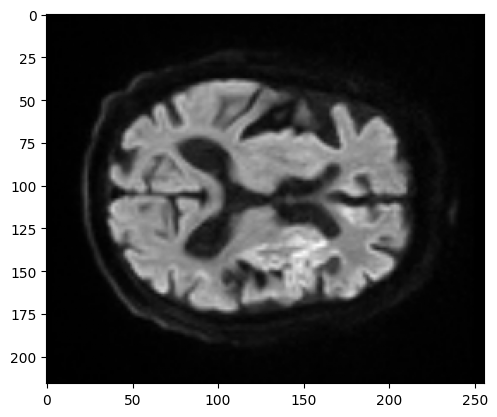

In [ ]:
plt.imshow(dwi_2[:, :, 72], cmap='gray')

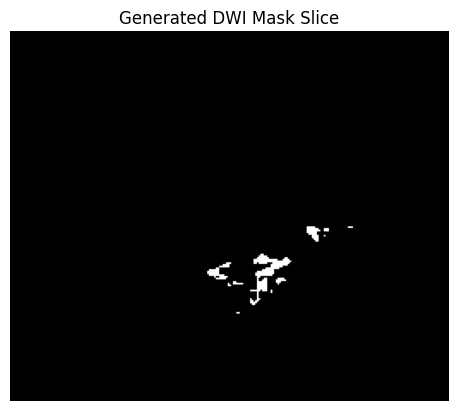

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# Load the DWI image (replace with your actual file path)
dwi_img = nib.load(root_dir/'corrected_DWI_20240101000000_3_in_T1.nii.gz')  # Or .nii
dwi_data = dwi_img.get_fdata()

# Create a mask by thresholding (you can adjust the threshold value)
# This threshold separates brain tissue from background
threshold = np.percentile(dwi_data, 98.9)  # You can try 80-95 based on data quality
mask = (dwi_data > threshold).astype(np.uint8)

# Optional: Keep only the largest connected component to remove noise
from scipy.ndimage import label
labeled_mask, num_features = label(mask)
largest_component = (labeled_mask == np.argmax(np.bincount(labeled_mask.flat)[1:]) + 1).astype(np.uint8)

# Save the mask to a NIfTI file
mask_img = nib.Nifti1Image(largest_component, affine=dwi_img.affine)
nib.save(mask_img, 'generated_dwi_mask.nii.gz')

# Show a slice for visual inspection
slice_index = 72
plt.imshow(largest_component[:, :, slice_index], cmap='gray')
plt.title("Generated DWI Mask Slice")
plt.axis('off')
plt.show()

In [ ]:
# simple thresholding mask
dwi_2_mask = nib.Nifti1Image(dwi_2>150, affine=dwi2_nii.affine, header=dwi2_nii.header)
#
dwi_2_mask = nib.Nifti1Image(largest_component, affine=dwi2_nii.affine, header=dwi2_nii.header)

dwi_2_mask.to_filename(root_dir/'N4ITKmask.nii.gz')

In [ ]:
dwi1_nii = nib.load(root_dir/'corrected_DWI.nii.gz')
dwi_1 = dwi1_nii.get_fdata()
dwi_1.shape

image_gray = dwi_1[:, :, 72]

# Define the block size and offset
block_size = 35
offset = 10

# Compute the local threshold
local_thresh = threshold_local(image_gray, block_size, offset=offset, method='gaussian')

# Apply the threshold
binary_image = image_gray > local_thresh

NameError: name 'threshold_local' is not defined

In [ ]:
# Display the results
plt.figure(figsize=(15, 6))  # Adjusted width to fit 5 images

plt.subplot(1, 4, 1)
plt.title('Original Image')
plt.imshow(image_gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title('Local Threshold')
plt.imshow(local_thresh, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title('Binary Image')
plt.imshow(binary_image, cmap='gray')
plt.axis('off')


plt.subplot(1, 4, 4)
plt.title('DWI Mask Slice')
plt.imshow(largest_component[:, :, slice_index], cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import requests
from bs4 import BeautifulSoup
import re

url = "https://surfer.nmr.mgh.harvard.edu/pub/dist/freesurfer/"
response = requests.get(url)
soup = BeautifulSoup(response.content, 'html.parser')

# Find all links on the page
links = soup.find_all('a')

versions = set()
# Look for patterns that resemble version numbers (e.g., X.Y.Z)
for link in links:
    text = link.get_text()
    match = re.search(r'\d+\.\d+\.\d+', text)
    if match:
        versions.add(match.group(0))

if versions:
    print("Found these FreeSurfer versions:")
    for version in sorted(list(versions), reverse=True):
        print(version)
else:
    print("Could not find FreeSurfer versions on the page.")

Found these FreeSurfer versions:
8.0.0
7.4.1
7.4.0
7.3.2
7.3.1
7.3.0
7.2.0
7.1.1
7.1.0
7.0.0
6.0.1
6.0.0
5.3.0
5.2.0
5.1.0
5.0.0
4.5.0
4.4.0
4.3.1
4.3.0
4.2.0
4.1.0
4.0.5
4.0.4
4.0.3
4.0.2
4.0.1
4.0.0
3.0.5
3.0.4
3.0.3
2.2.0
0.8.0
0.7.0


In [ ]:
import os
import stat

fs_bin_dir = "/opt/freesurfer/bin"
print(f"Contents of {fs_bin_dir}:")
if os.path.exists(fs_bin_dir):
    for item in os.listdir(fs_bin_dir):
        item_path = os.path.join(fs_bin_dir, item)
        is_executable = " (executable)" if os.path.isfile(item_path) and os.access(item_path, os.X_OK) else ""
        print(f"- {item}{is_executable}")
else:
    print(f"Directory not found: {fs_bin_dir}")

Contents of /opt/freesurfer/bin:
Directory not found: /opt/freesurfer/bin


In [52]:
import os

# Inspect the contents of the 'Raw' directory for PATIENT100
raw_dir_to_inspect = '/content/drive/My Drive/AHWFB/'

print(f"Contents of {raw_dir_to_inspect}:")
if os.path.exists(raw_dir_to_inspect):
    print(os.listdir(raw_dir_to_inspect))
else:
    print(f"Directory not found: {raw_dir_to_inspect}")

Contents of /content/drive/My Drive/AHWFB/:
['Patient44']


In [47]:
import os

# List the contents of the root of your mounted drive
drive_root = '/content/drive/My Drive/'
print(f"Contents of {drive_root}:")
if os.path.exists(drive_root):
    print(os.listdir(drive_root))
else:
    print(f"Directory not found: {drive_root}")

Contents of /content/drive/My Drive/:
['AHWFB']


In [50]:
import os

# Inspect the contents of the 'AHWFB' directory
ahwfb_dir = '/content/drive/My Drive/AHWFB/'

print(f"Contents of {ahwfb_dir}:")
if os.path.exists(ahwfb_dir):
    print(os.listdir(ahwfb_dir))
else:
    print(f"Directory not found: {ahwfb_dir}")

Contents of /content/drive/My Drive/AHWFB/:
['Patient44']
